<a href="https://colab.research.google.com/github/ThasMorr23/data-analytics-portfolio/blob/main/sentiment-analysis-amazon-reviews/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of Amazon Product Reviews

This project builds a binary text classification model to predict whether a product review is positive or negative using natural language processing (NLP) and a neural network implemented with TensorFlow/Keras.

## Objective

Customer reviews contain valuable insights, but analyzing them at scale is challenging. The goal of this project is to develop a machine learning model that classifies reviews as positive or negative based on their text content.

This enables businesses to better understand customer sentiment and make data-driven decisions.

In [48]:
import pandas as pd
import numpy as np
import re
import random
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [49]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## Data Loading

The dataset consists of labeled product reviews, where each review is classified as either positive or negative.

In [50]:
df1 = pd.read_csv('amazon_cells_labelled.txt', delimiter='\t', header=None, names=['Reviews', 'Sentiment'])
df2 = pd.read_csv('yelp_labelled.txt', delimiter='\t', header=None, names=['Reviews', 'Sentiment'])
df3 = pd.read_csv('imdb_labelled.txt', delimiter='\t', header=None, names=['Reviews', 'Sentiment'])
df = pd.concat((df1, df2, df3), ignore_index=True)

df.columns = ['review', 'sentiment']

In [51]:
print(df.shape)
df.head()

(2748, 2)


,review,sentiment
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


## Data Cleaning and Preprocessing

The dataset was cleaned by:
- Removing duplicates
- Handling missing values
- Converting text to lowercase
- Removing special characters and extra spaces

In [52]:
df = df.drop_duplicates().dropna()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text)   # remove punctuation/special chars
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

df["review"] = df["review"].apply(clean_text)

## Tokenization and Padding

Text data must be converted into numerical format before being used in a neural network. This is done using tokenization and padding.

In [53]:
review_lengths = df["review"].apply(lambda x: len(x.split()))
print(review_lengths.describe())

max_length = int(review_lengths.quantile(0.95))
vocab_size = 5000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['review'])

sequences = tokenizer.texts_to_sequences(df['review'])
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

count    2731.000000
mean       13.004760
std        35.781628
min         1.000000
25%         6.000000
50%        10.000000
75%        16.000000
max      1384.000000
Name: review, dtype: float64


In [54]:
X = padded_sequences
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model Architecture

A neural network model is used for binary classification. The model includes:
- Embedding layer for word representation
- Global average pooling
- Dropout for regularization
- Dense output layer with sigmoid activation

In [55]:
model = Sequential([
    Embedding(vocab_size, 32, input_length=max_length),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Training

The model is trained using early stopping to prevent overfitting.

In [56]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6022 - loss: 0.6692 - val_accuracy: 0.6430 - val_loss: 0.6898
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8122 - loss: 0.4970 - val_accuracy: 0.7437 - val_loss: 0.6733
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9101 - loss: 0.2889 - val_accuracy: 0.7643 - val_loss: 0.6427
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9599 - loss: 0.1633 - val_accuracy: 0.7666 - val_loss: 0.6052
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9760 - loss: 0.0938 - val_accuracy: 0.7300 - val_loss: 0.5656
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9857 - loss: 0.0596 - val_accuracy: 0.6636 - val_loss: 0.5598
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9891 - loss: 0.0505 - val_accuracy: 0.7323 - val_loss: 0.4928
Epoch 8/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9908 - loss: 0.0367 - val_accuracy: 0.7506 - val_loss:

## Model Performance

In [57]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7861 - loss: 0.5326 
Test Accuracy: 0.7861
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


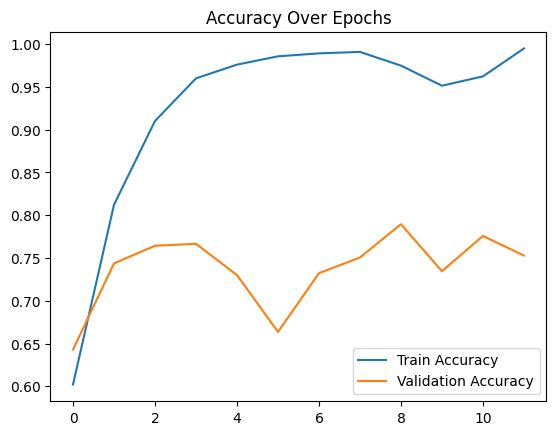

In [58]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Over Epochs")
plt.show()

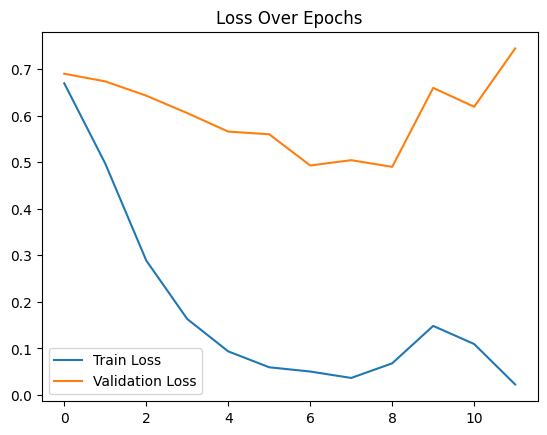

In [59]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Over Epochs")
plt.show()

## Conclusion

The final neural network achieved approximately 78% test accuracy in classifying review sentiment as positive or negative. This indicates that the model was able to capture meaningful sentiment patterns in the review text while maintaining a workflow that is interpretable and reproducible.

Although performance was slightly below the highest result achieved during earlier experimentation, the final version was selected because it balances predictive performance with a cleaner, more professional pipeline suitable for portfolio presentation.

## Next Steps

- Tune hyperparameters (embedding size, dropout, learning rate)
- Compare with simpler models (logistic regression)
- Try advanced architectures (LSTM, GRU)
- Use larger or more diverse datasets

## Simulated Real-World Deployment

In a real-world setting, this sentiment analysis model would be deployed to automatically classify incoming customer reviews. Rather than analyzing a static dataset, the model would process new reviews in real time, enabling continuous monitoring of customer sentiment.

To simulate this process, a small set of new reviews is passed through the trained model, and the results are aggregated to demonstrate how businesses can track sentiment trends and generate actionable insights.

In [60]:
def predict_review(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_length, padding="post")

    pred = model.predict(padded, verbose=0)[0][0]

    return "Positive" if pred > 0.5 else "Negative"

### Generating Predictions on New Data

The following sample reviews simulate new customer feedback entering the system.

In [61]:
new_reviews = pd.DataFrame({
    "review": [
        "This product is amazing, I love it!",
        "Terrible quality, broke after one use",
        "Pretty decent for the price",
        "Not worth the money at all",
        "Exceeded my expectations, highly recommend"
    ]
})

new_reviews

,review
0,"This product is amazing, I love it!"
1,"Terrible quality, broke after one use"
2,Pretty decent for the price
3,Not worth the money at all
4,"Exceeded my expectations, highly recommend"


In [62]:
new_reviews["predicted_sentiment"] = new_reviews["review"].apply(predict_review)

new_reviews

,review,predicted_sentiment
0,"This product is amazing, I love it!",Positive
1,"Terrible quality, broke after one use",Negative
2,Pretty decent for the price,Positive
3,Not worth the money at all,Negative
4,"Exceeded my expectations, highly recommend",Positive


### Aggregating Sentiment Results

Individual predictions are useful, but businesses typically analyze sentiment at an aggregate level to identify trends and patterns.

In [63]:
sentiment_counts = new_reviews["predicted_sentiment"].value_counts()
sentiment_percent = new_reviews["predicted_sentiment"].value_counts(normalize=True) * 100

print("Counts:")
print(sentiment_counts)

print("\nPercentages:")
print(sentiment_percent)

Counts:
predicted_sentiment
Positive    3
Negative    2
Name: count, dtype: int64

Percentages:
predicted_sentiment
Positive    60.0
Negative    40.0
Name: proportion, dtype: float64


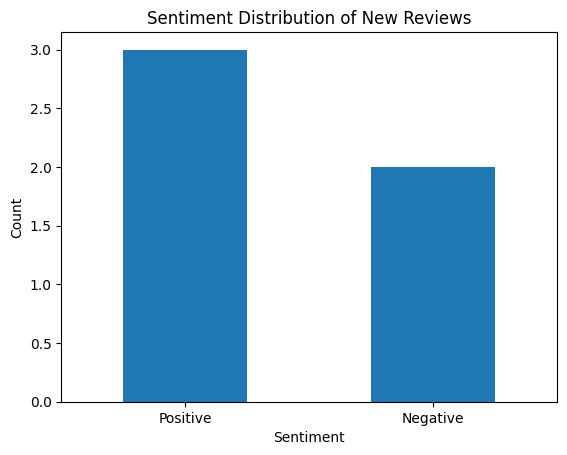

In [64]:
import matplotlib.pyplot as plt

sentiment_counts.plot(kind="bar", title="Sentiment Distribution of New Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Business Insights

This simulated workflow demonstrates how sentiment predictions can be used to generate actionable insights:

- A high percentage of negative reviews may indicate product quality or customer experience issues  
- Positive sentiment trends can highlight successful products or features  
- Monitoring sentiment over time allows teams to quickly detect shifts in customer perception  

In a production environment, these results would feed into dashboards and reporting systems, enabling teams such as product development, marketing, and customer support to make data-driven decisions.

### Next Steps for Production Deployment

To transition this system into a real-world application, the following steps would be required:

- Integrate the model with a live data source (e.g., database or API)
- Automate prediction on incoming reviews
- Store predictions for historical tracking and analysis
- Build dashboards to visualize sentiment trends over time
- Continuously retrain the model with new data to improve performance